# **Cutzamala System - Time Series Analysis of Drought Conditions**

**1) Introduction**
> 1.1) Description of the problem  
> 2.2) Theoretical background
  
**2) Prepare for execution**
> 2.1) Load used libraries

**3) Data ETL Process**
> 3.1) Fetch and save data  
> 3.2) Define auxiliary functions
> 3.3) Data cleaning and imputation
> 3.4) Validate transformations
  
**3) Exploratory Data Analysis**
> 3.1) Moving average of storage  
> 3.2) Differences in storage  
> 3.3) Historical comparisson per season  

**4) TSA Modelling**
> 1.1) Data transformations  
> 4.2) Identifying model order

**5) Hyperparameter tuning**
> 5.1) Grid Search

**6) Model validation**

**7) Conclusions**

# **1) Introduction**

# **2)Prepare For Execution** 

## **2.1) Used libraries**

**In this cell:**  
1) Libraries used along the whole NB are imported here.

**Notes:**  
- Each code line is commented to trace it's usage in the process.

In [164]:
# General purpose
import pandas as pd
import numpy as np
import time
import warnings

# Define working directory
import os
main_folder = os.getcwd()

# Data visualization
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# Perform Box Cox transformations
from scipy.stats import boxcox, boxcox_normmax

# Perform stationarity test for time series
from statsmodels.tsa.stattools import adfuller

# Normally generate random numbers anc test for normality
from scipy.stats import norm
from scipy.stats import jarque_bera

# Compuyte ACF and PACF of a time series
from statsmodels.tsa.stattools import acf, pacf

# Fit ARMA models
import statsmodels.api as sm
import statsmodels

# Cell breaker
print("="*100)
print("All libreries were succesfully imported!")
print("="*100)

All libreries were succesfully imported!


# **3) ELT Process**

## **3.1) Fetch data and save raw files**

**In this cell:**  
1) The dams to be analyzed are listed. They are named in an abbreviated form, and a 
2) Query the SIH server, fetch the data and save it locally

**Notes:**  
- Server might be unavailable and this cell can be ommited to execute the rest of the NB

In [37]:
# Define dams to be analyzed and URL for downloading data
dams = ["VB", "BO", "VV"]
dam_code = {"VB":"VBRMX", "BO":"DBOMC", "VV":"VVCMX"}
dam_name = {"VB":"Valle de Bravo", "BO":"El Bosque", "VV":"Villa Victoria"}
url = f"https://sih.conagua.gob.mx/basedatos/Presas"

# For each dam, data is downloaded and saved locally
for dam in dams:
    df_raw = pd.read_csv(f"{url}/{dam_code[dam]}.csv", encoding="utf8", skiprows=7)
    df_raw.to_csv(f"{main_folder}/Data/Raw/{dam_code[dam]}.csv", index=False)

# Cell breaker
print("="*100)
print("Data has been downloaded and saved!")
print("="*100)

Data has been downloaded and saved!


## **3.2) Define auxiliary functions**

**In this cell:**  
1) In order to keep track of missing data, this function is auxiliary to count the maximum consecutive days that are missing on the fetch records.

**Notes:**  
- Due to the short length of the records, optimization might not be required

In [38]:
# dDefine auxiliary function
def longest_streak(sequence):
    """
    Gets a sequence of True and False and returns the max number of consecutive Trues
    """
    
    # Iterate over the elements in the list to count the max number of consecutive Trues
    max_streak = 0
    current_streak = 0
    for element in sequence:
        
        # For each element in the 
        if element==True:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0

    # Return the max number of consecutive Trues
    return max_streak

print

<function print>

## **3.3) Data cleaning and imputation**

**In this cell:**  
1) Read fetch data for each dam, put the data in a clear format and merge all the data in a single df
2) Define thee index of the recods in a proper datetime format and filter data to analysis period
3) Data imputation is performed
4) A record of missing values is kept 

**Notes:**  
- **IMPORTANT**  
Data is filtered to start on 1994
- **IMPORTANT**  
Missing data is imputated with a linear regression, filling gaps between valid values.

In [39]:
# Define column names of df with storage data
col_names = ["date", "storage"]

# Read individual storage levels per dam and 
df_storage = pd.DataFrame()
for dam in dams:
    df_dam = pd.read_csv(f"{main_folder}/Data/Raw/{dam_code[dam]}.csv", usecols=[0,2], names=col_names, index_col=0, skiprows=1)
    df_storage[dam] = df_dam["storage"]

# Convert storage dtypes to numeric and index to datetime
df_storage = df_storage.apply(pd.to_numeric, errors="coerce", axis=1)
df_storage.index = pd.to_datetime(df_storage.index, format="%Y/%m/%d")

# Filter data to preserve records starting from 1994
df_storage = df_storage[df_storage.index.year >= 1994].copy()

# Check missing data
n_missing = df_storage.isnull().sum().sum()
longest = {dam:longest_streak(df_storage[dam].isnull().to_list()) for dam in dams}

# Interpolate missing values
missing = df_storage.isnull().sum(axis=1)[1==df_storage.isnull().sum(axis=1)].index
df_storage = df_storage.interpolate(method="linear", axis=0)

# Cell breaker
print("="*100)
print(f"A total of {n_missing} values were imputated")
print(f"The values were present in {len(missing)} different days")
print("="*100)
print("Longest consecutive days of missing values:\n",longest)
print("="*100)

A total of 53 values were imputated
The values were present in 44 different days
Longest consecutive days of missing values:
 {'VB': 16, 'BO': 2, 'VV': 2}


## **3.4) Data transformation**

### **3.4.1) Average storage per season**

**In this cell:**  
1) The daily storage average is computed for each year-season.

**Notes:**  
- The aaggregated storage is considered. The three dams in the system are combined and the analysis is performed with the System as a whole

- Seasons are defined as metereological seasons, grouppiong months instead of astronomical events. For example
> _DJF: December, January and February  
> MAM: March, April, May  
> JJA; June, July, August  
> SON: September, October, November_  

- December of the year YYYY is considered in the season "DEF" of the year YYYY+1

In [40]:
# Create temporal df for data manipulation
df_temporal = df_storage.copy()
df_temporal["ALL"] = df_storage.sum(axis=1)

# Define year column. December is assigned to next year
df_temporal["year"] = np.where(df_temporal.index.month==12, df_temporal.index.year+1, df_temporal.index.year)

# Define custom seasons and assign accordingly to month
map_season = {12:"DJF", 1:"DJF", 2:"DJF", 3:"MAM", 4:"MAM", 5:"MAM",
              6:"JJA", 7:"JJA", 8:"JJA", 9:"SON", 10:"SON", 11:"SON"}
df_temporal["season"] = df_temporal.index.month.map(map_season)

# Save resultant df in other variable
df_season = df_temporal.copy()

# Cell breaker
print("="*100)
print("Season averages were computed")
print("="*100)

Season averages were computed


### **3.4.2) Create a timeseries with the storage**

**In this cell:**
1) The created series with the averages is transformed into a time series (TS), properly indexing it.

**Notes:**
- The final day of each season is taken as representative of it.

In [41]:
# Create time series with the average per year and season
ts_storage = df_season.groupby(["year", "season"])["ALL"].mean()

# Define the correct order of the seasons and Reindex the grouped result to enforce the order
years = [i for i in range(df_storage.index.year.min(), df_storage.index.year.max()+1)]
seasons = ["DJF", "MAM", "JJA", "SON"]
multi_index = pd.MultiIndex.from_product([years, seasons], names=["year", "season"])
ts_storage = ts_storage.reindex(multi_index).round(4)
ts_storage.name = "storage"

# Reindex TS to date format
map_season_date = {"DJF":"02-28", "MAM":"05-31", "JJA":"08-31", "SON":"11-30"}
years = ts_storage.index.get_level_values("year")
dates = ts_storage.index.get_level_values("season").map(map_season_date)
ts_storage.index = pd.to_datetime([f"{year}-{date}" for year, date in zip(years, dates)])

# Drop NAN values, created when reindexing as date format
ts_storage.dropna(inplace=True)

# Cell breaker
print("="*100)
print("The time series with the daily average storage per season has been created!")
print("="*100)

The time series with the daily average storage per season has been created!


### **3.3.3) Perform data transformations**

**In this cell:**
1) The percentage of usable storage (PUS) is calculated
2) The odds of the the PUS are computed, then, a box cox transformation is applied

**Notes:**
- The time series is trimed to match it with the analysis performed in my research
- **IMPORTANT**  
The time series is trimed to match it with the analysis performed in my research
- **IMPORTANT**  
The $\lambda$ value for the BoxCox transformation is obtained externally from R. It follows a differeent optimization method than the one in Python's libraries

In [42]:
# Define storage levels
namino = 140
namo = 782.521

# Save untrimmed TS
ts_storage_complete = ts_storage.copy()

# Perform data transformations
ts_storage = ts_storage[ts_storage.index <= "2024-09-01"]
ts_data = ts_storage.copy()
ts_data = (ts_data-namino) / (namo-namino)
ts_odds = ts_data / (1-ts_data)

# Perform BoxCox transformation
lambda_value = -0.2399351
# lambda_value = boxcox_normmax(ts_odds, method="mle")
ts_transformed = pd.Series(boxcox(ts_odds, lmbda=lambda_value), index=ts_odds.index)

### **3.3.4) Validate transformations**

**In this cell:**
1) An Augmented Dickey Fullter test for stationarity (unit roots) is performed

**Notes:**
- ADF test has as null hypothesis that the series is not stationary. Hence, a low pvalue indicates that there's low evidence of it, and the alternative hypothesis should be accepted. In other words, a low pvalue indicates stationarity.

In [43]:
# Perform the ADF test and extract the pvalue
pvalue = adfuller(ts_transformed, maxlag=4)[1]

# Cell breaker
print("="*100)
print(f"pvalue: {pvalue:.3f}\nTherefore, the transformed series is stationary\nProceed with TS analysis")
print("="*100)

pvalue: 0.005
Therefore, the transformed series is stationary
Proceed with TS analysis


# **4) Exploratory Data Analysis**

## **4.1) Moving average of storage**

**In this cell:**
1) The chart and the needed data are created

**Notes:**
- The current state of the System is a historical-low

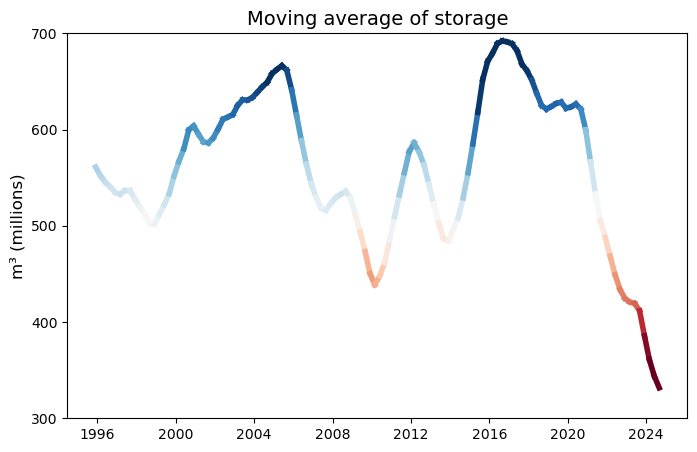

In [44]:
# Set up chart
plt.figure(figsize=(8,5))

# Get data for plotting
ts_temporal = ts_storage.rolling(8).mean().dropna()
values = ts_temporal.values
index = ts_temporal.index

# Get the colormap
cmap = matplotlib.colormaps["RdBu"]
vmin, vmax = values.min()*1.05, values.max()*0.95

# Plot every segment with different colors
for i in range(len(values)-1):
    x1, x2 = index[i], index[i+1]
    y1, y2 = values[i], values[i+1]
    normalized = (y2-vmin) / (vmax-vmin)  
    plt.plot((x1,x2),(y1,y2), linewidth=4, color=cmap(normalized))

# Graph details
plt.ylabel("m³ (millions)", fontsize=12)
plt.ylim(300,700), plt.yticks([i*100 for i in range(3,8)], [i*100 for i in range(3,8)], fontsize=10)
plt.title("Moving average of storage", fontsize=14)
plt.show()

## **4.2) Differences in storage**

**In this cell:**
1) The chart and the needed data are created

**Notes:**
- A poor recovery in the last rain seasons might be the reason for the drought conditions

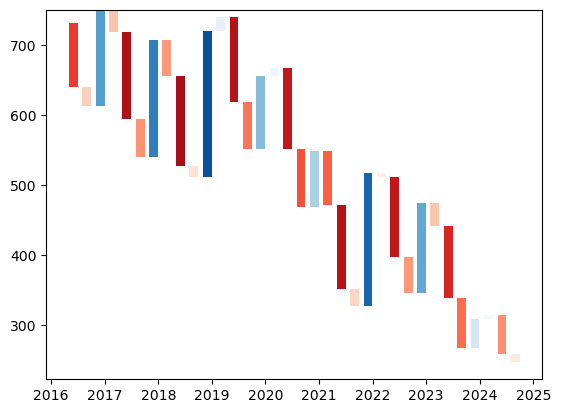

In [45]:
ts_temporal = ts_storage[ts_storage.index >= "01-01-2016"]
difference = ts_temporal.diff(1).dropna()

cmap_blues = matplotlib.colormaps["Blues"]
cmap_reds = matplotlib.colormaps["Reds"]
vmin, vmax = difference.min()*1.15, difference.max()*1.15
colors = [cmap_blues(diff/vmax) if diff>0 else cmap_reds(diff/vmin) for diff in difference]

# Create a bar plot
plt.bar(difference.index, difference, bottom=ts_temporal[:-1:], width=60, color=colors)


plt.show()

## **4.3) Historical comparisson per season**

**In this cell:**
1) The chart and the needed data are created

**Notes:**
- For the last 4 seasons, storage on record correspond to historical minimum, with a high spread from usual values

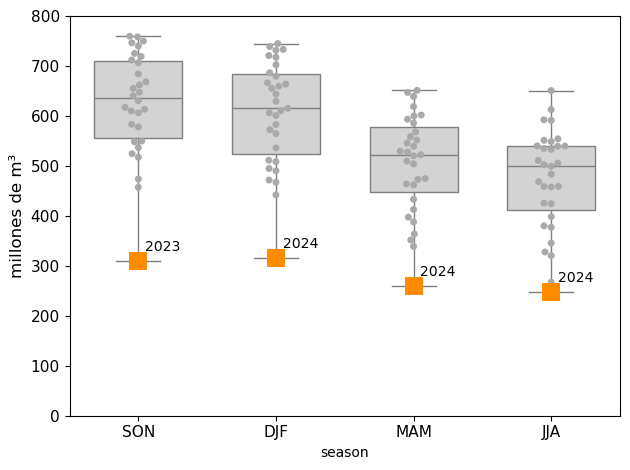

In [46]:
# Define the temporal df to store data for plotting and order the order of the seasons
df_temporal = pd.DataFrame(data=ts_storage)
df_temporal["season"] = df_temporal.index.month.map({11:1, 2:2, 5:3, 8:4})

# Prepare figure to plot
fig,ax = plt.subplots(1,1)

# Plot the boxplot
sns.boxplot(x="season", y="storage", hue="season", palette={i:"lightgray" for i in range(5)},
            legend=False, gap=0.2, whis=2,data=df_temporal, ax=ax)

# Plot the historical records
sns.swarmplot(x="season", y="storage", hue="season", palette={i:"darkgrey" for i in range(5)}, legend=False,
              data=df_temporal, ax=ax)

# Plot the historical minimum of the records
df_min = df_temporal.loc[df_temporal.groupby(["season"]).idxmin()["storage"], :]
sns.swarmplot(x="season", y="storage", s=12.5, hue="season", legend=False,
              marker="s", palette={i:"darkorange" for i in range(5)},
              data=df_min, ax=ax)

#
for x,y in df_min.iterrows():
    ax.text(x=y["season"]-0.95, y=y["storage"]+20, s=x.year, fontsize=10)

# Set xticks at specific positions with custom labels
positions = [0, 1, 2, 3]
labels = ["SON", "DJF", "MAM", "JJA"]
ax.set_xticks(positions, labels, fontsize=11)


ax.set_ylabel("millones de m³", fontsize=12)
ax.set_yticks([i*100 for i in range(9)], [i*100 for i in range(9)], fontsize=11)
plt.tight_layout()
plt.show()

# **5) Time Series Modelling**

## **5.1) Define auxliary functions**

### **5.1.1) Plot TS with ACF and PACF**

**In this cell:**
1) A function to created to Plot a TS along with it's ACF and PACF graphs
2) Define the plot grid
3) Plot the time series
4) Plot the ACF and the PCAF graphs

**Notes:**
- The function resembles _"ggtsdisplay()"_ from the forecast library in R.
- To compute the PACF, the chosen method is "ldbiased", just as in R

In [47]:
def plot_ts(ts_plot):

    """
    Plot a TS along with it's ACF and PACF graphs

    Parameters:
    ts_plot (pd.Series): The time series to be plotted. Make sure to input it with
                         a valid datetime index and without missing values.

    Returns:
    NULL. Automatically created the plot
    """
    
    # Create a figure and define the grid layout: 2 rows, 2 columns
    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 2, figure=fig)
    
    
    

    
    # TS - Plot the time series trajectory and scatterplot with the observations
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(ts_plot, linewidth=1, color="black") 
    ax1.scatter(ts_plot.index, ts_plot, marker="s", s=4.5, color="black")
    
    # TS - Set x ticks
    x_labels = np.linspace(ts_plot.index.min().year, ts_plot.index.max().year, 7).astype(int)
    x_positions = np.vectorize(lambda year: f"{year}-01-01")(x_labels)
    ax1.set_xticks(x_positions, x_labels, fontsize=8)
    
    # TS - Set y ticks
    y_labels = np.linspace(ts_plot.min(), ts_plot.max(), 5).round(1)
    y_positions = y_labels
    ax1.set_yticks(y_positions, y_labels, fontsize=8)
    
    # TS - Remove the box lines in chart
    ax1.spines["top"].set_visible(False), ax1.spines["right"].set_visible(False)
    
    
    
    
    
    # ACF - Create axes and calculate sample acf
    ax2 = fig.add_subplot(gs[1, 0])
    points = pd.Series(acf(ts_plot, nlags=30)).iloc[1:]
    
    # ACF - Plot sample ACF
    for x,y in points.items():
        ax2.plot((x,x), (0,y), linewidth=1, color="black")
    ax2.plot((0, 1+points.shape[0]), (0,0), c="black", linewidth=1)
    ax2.set_ylabel("ACF", fontsize=10)
    
    # Plot confidence intervals
    ci = 1.96/ts_plot.shape[0]**0.5
    ax2.plot((0, 1+points.shape[0]), (ci, ci), linewidth=1, c="blue", linestyle=(4,(4,4)))
    ax2.plot((0, 1+points.shape[0]), (-ci, -ci), linewidth=1, c="blue", linestyle=(4,(4,4)))
    
    # ACF - Define xticks, xlims and set xlabel
    x_ticks = [0,4,8,12,16,20,24,28]
    ax2.set_xticks(x_ticks, x_ticks, fontsize=8)
    ax2.set_xlim(0, 1+points.shape[0])
    ax2.set_xlabel("Lag", fontsize=10)
    
    # ACF - Save min and max values (used later to define yticks and ylims)
    acf_min = points.min()
    acf_max = points.max()
    
    # ACF - Remove the box lines in chart
    ax2.spines["top"].set_visible(False), ax2.spines["right"].set_visible(False)
    
    
    
    
    
    # PACF - Create axes and calculate sample acf
    ax3 = fig.add_subplot(gs[1, 1])
    points = pd.Series(pacf(ts_plot, nlags=30, method="ldbiased")).iloc[1:]
    
    # PACF - Plot sample PACF
    for x,y in points.items():
        ax3.plot((x,x), (0,y), linewidth=1, color="black")
    ax3.plot((0, 1+points.shape[0]), (0,0), c="black", linewidth=1)
    ax3.set_ylabel("PACF", fontsize=10)
    
    # PCAF - Plot confidence intervals
    ci = 1.96/ts_plot.shape[0]**0.5
    ax3.plot((0, 1+points.shape[0]), (ci, ci), linewidth=1, c="blue", linestyle=(4,(4,4)))
    ax3.plot((0, 1+points.shape[0]), (-ci, -ci), linewidth=1, c="blue", linestyle=(4,(4,4)))
    
    # PACF - Define x ticks, x lims and set x klabel
    x_ticks = [0,4,8,12,16,20,24,28]
    ax3.set_xticks(x_ticks, x_ticks, fontsize=8)
    ax3.set_xlim(0, 1+points.shape[0])
    ax3.set_xlabel("Lag", fontsize=10)
    
    # PACF - Save min and max values (used later to define yticks and ylims)
    pacf_min = points.min()
    pacf_max = points.max()
    
    # PACF - Remove the box lines in chart
    ax3.spines["top"].set_visible(False), ax3.spines["right"].set_visible(False)

    
    
    
    
    
    # Define y ticks for ACF and PACF plots
    ar_temporal = np.array([acf_min, pacf_min, acf_max, pacf_max])
    value = (np.floor(np.abs(ar_temporal * 2/3 / 0.2)) * 0.2).max()
    ax2.set_yticks([-value,0,value], [-value,0,value])
    ax3.set_yticks([-value,0,value], [-value,0,value])
    
    # Define Y lims for ACF and PACF plots
    value = np.abs(ar_temporal).max()*1.1
    ax2.set_ylim([-value, value])
    ax3.set_ylim([-value, value])
    
    
    
    
    
    # Adjust layout to prevent overlap and show the plot
    plt.suptitle("Time Series")
    plt.tight_layout()
    plt.show()

### **5.1.2) Plot residuals with ACF and histogram**

**In this cell:**
1) A function to created to Plot the residuals of the model along with it's ACF and histogram
2) Define the plot grid
3) Plot the time series
4) Plot the ACF and the PCAF graphs

**Notes:**
- The function resembles _"cueckresiduals()"_ from the forecast library in R.

In [48]:
def plot_residuals(residuals):

    """
    Plot a TS along with it's ACF and PACF graphs

    Parameters:
    residuals (pd.Series): The time series to be plotted. Make sure to input it with
                         a valid datetime index and without missing values.

    Returns:
    NULL. Automatically created the plot
    """
    
    # Create a figure and define the grid layout: 2 rows, 2 columns
    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 2, figure=fig)
    
    
    

    
    # RES - Plot the time series trajectory and scatterplot with the observations
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(residuals, linewidth=1, color="black") 
    ax1.scatter(residuals.index, residuals, marker="s", s=4.5, color="black")
    
    # RES - Set x ticks
    x_labels = np.linspace(residuals.index.min().year, residuals.index.max().year, 7).astype(int)
    x_positions = np.vectorize(lambda year: f"{year}-01-01")(x_labels)
    ax1.set_xticks(x_positions, x_labels, fontsize=8)
    
    # RES - Set y ticks
    y_labels = np.linspace(residuals.min(), residuals.max(), 5).round(1)
    y_positions = y_labels
    ax1.set_yticks(y_positions, y_labels, fontsize=8)
    
    # RES - Remove the box lines in chart
    ax1.spines["top"].set_visible(False), ax1.spines["right"].set_visible(False)

    # RES - Horizontal line at x=0
    ax1.axhline(0, color="blue", alpha=0.5, linewidth=0.5)
    
    
    
    
    
    # ACF - Create axes and calculate sample acf
    ax2 = fig.add_subplot(gs[1, 0])
    points = pd.Series(acf(residuals, nlags=30)).iloc[1:]
    
    # ACF - Plot sample ACF
    for x,y in points.items():
        ax2.plot((x,x), (0,y), linewidth=1, color="black")
    ax2.plot((0, 1+points.shape[0]), (0,0), c="black", linewidth=1)
    ax2.set_ylabel("ACF", fontsize=10)
    
    # Plot confidence intervals
    ci = 1.96/residuals.shape[0]**0.5
    ax2.plot((0, 1+points.shape[0]), (ci, ci), linewidth=1, c="blue", linestyle=(4,(4,4)))
    ax2.plot((0, 1+points.shape[0]), (-ci, -ci), linewidth=1, c="blue", linestyle=(4,(4,4)))
    
    # ACF - Define xticks, xlims and set xlabel
    x_ticks = [0,4,8,12,16,20,24,28]
    ax2.set_xticks(x_ticks, x_ticks, fontsize=8)
    ax2.set_xlim(0, 1+points.shape[0])
    ax2.set_xlabel("Lag", fontsize=10)
    
    # ACF - Save min and max values (used later to define yticks and ylims)
    acf_min = points.min()
    acf_max = points.max()
    
    # ACF - Remove the box lines in chart
    ax2.spines["top"].set_visible(False), ax2.spines["right"].set_visible(False)

    # ACF - Define y ticks for ACF plot
    ar_temporal = np.array([acf_min, acf_max])
    value = ((np.abs(ar_temporal * 2/3 / 0.2)) * 0.2).round(2).max()
    ax2.set_yticks([-value,0,value], [-value,0,value])
    
    # ACF - Define ylims for ACF plot
    value = np.abs(ar_temporal).max()*1.1
    ax2.set_ylim([-value, value])




    
    # HIST - Create axes and calculate sample acf
    ax3 = fig.add_subplot(gs[1, 1])

    # HIST - Create histogram and get max count to normalize pdf
    hist = sns.histplot(residuals, ax=ax3, color="dimgray", bins=np.ceil(residuals.shape[0]/8).astype(int), alpha=1,
                        edgecolor=None, linewidth=0, stat="count")
    max_count = max([p.get_height() for p in hist.patches])
    
    # HIST - Overlay normal distribution
    mu, sigma = residuals.mean(), residuals.std()
    xlim = np.abs(residuals).max()
    x = np.linspace(-xlim, xlim, 100)
    pdf = norm.pdf(x, mu, sigma)
    ax3.plot(x, pdf/pdf.max()*0.90*max_count, color="blue", linewidth=0.5)

    # HIST - Define ticks
    yticks = np.ceil(np.linspace(0,max_count,5)).astype(int)
    ax3.set_yticks(yticks, yticks, fontsize=8), ax3.set_ylabel("count", fontsize=10)
    xticks = np.linspace(residuals.min(), residuals.max(), 5).round(1)
    ax3.set_xticks(xticks, xticks, fontsize=8), ax3.set_xlabel("residuals", fontsize=10)
    

    
    
    
    # Adjust layout to prevent overlap and show the plot
    plt.suptitle("Time Series")
    plt.tight_layout()
    plt.show()

## **5.2) Propose an initial model**

### **5.2.1) Analyze ACF and PACF**

**In this cell:**
1) Plott the sample ACF and PACF diagrams

**Notes:**
- The first look at the ACF and PACF diagrams suggest that a regular differentiation might be needed befor adjusting an ARMA model

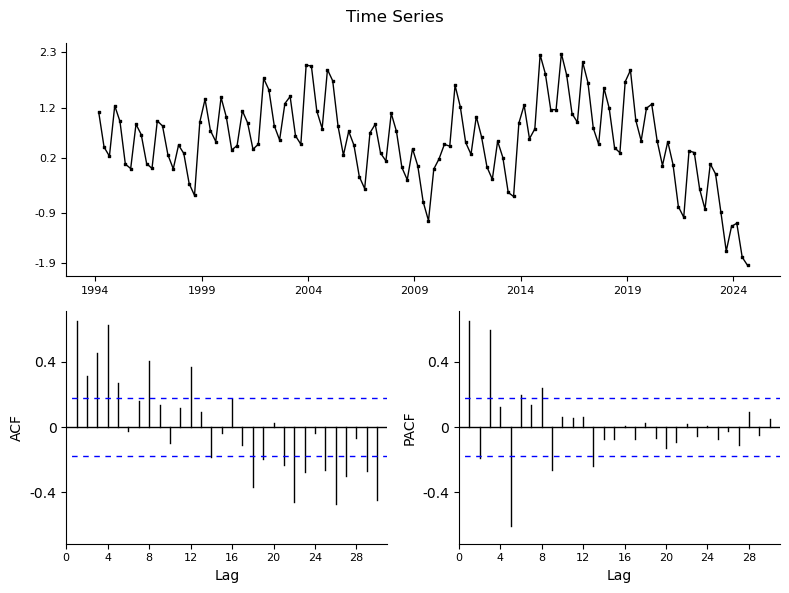

In [49]:
plot_ts(ts_transformed)

### **5.2.2) Regular differentiation**

**In this cell:**
1) The series with regular differentiation ($d=1$) is plotted and analyzed.

**Notes:**
- Seasonal dependency is observed in the ACF of the series.

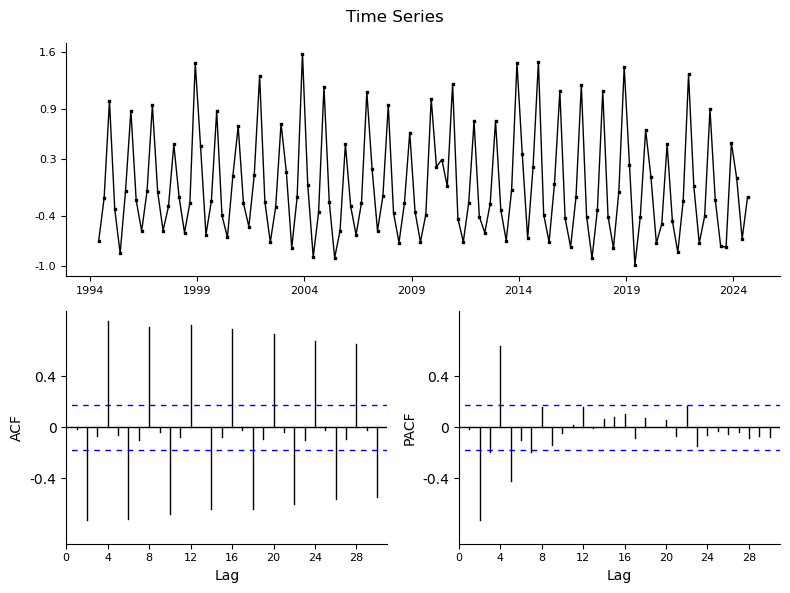

In [50]:
ts_transformed_1_0 = ts_transformed.diff(1).dropna()
plot_ts(ts_transformed_1_0)

### **5.2.3) Seasonal differentiation**

**In this cell:**
1) Seasonal differentiation is applied to the previous series.

**Notes:**
- This series $(d=1, D=1)$ is selected to run the fit the first model.
- **IMPORTANT**  
The proposed model is of the order ($p=1, P=4$) because of the analysis drawn of the PACF diagram.

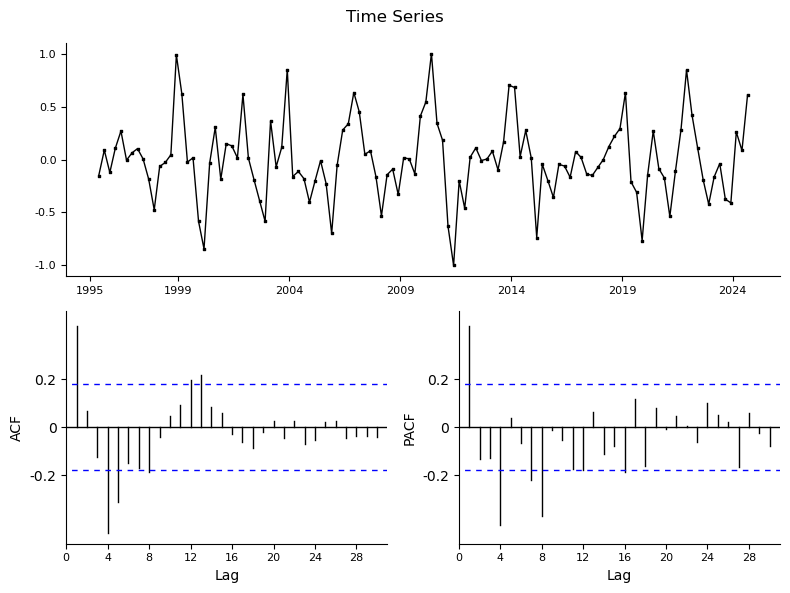

In [51]:
ts_transformed_1_1 = ts_transformed_1_0.diff(4).dropna()
plot_ts(ts_transformed_1_1)

## **5.3) Estimate parameters**

**In this cell:**
1) The time series index is modified to match a structured Quarterly format
2) The model is fitted and the coefficients are estimated

**Notes:**
- **IMPORTANT**  
All the coefficients turned out statistically significant, except SAR4

In [52]:
# Define the TS to be fitted by the model
ts_model = ts_transformed
ts_model.index = pd.date_range(start=ts_model.index.min(), periods=len(ts_model), freq="QE")

# Define the order of the model
order = (1,1,0)
seasonal_order = (4,1,0,4)

# Fit the model and print results
model = sm.tsa.ARIMA(ts_model, order=order, seasonal_order=seasonal_order).fit()
model.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,0.3323,0.079,4.201,0.000,0.177,0.487
ar.S.L4,-0.7714,0.088,-8.786,0.000,-0.943,-0.599
ar.S.L8,-0.7060,0.133,-5.301,0.000,-0.967,-0.445
ar.S.L12,-0.3720,0.126,-2.957,0.003,-0.619,-0.125
ar.S.L16,-0.2069,0.087,-2.376,0.017,-0.378,-0.036
sigma2,0.0645,0.008,8.519,0.000,0.050,0.079


## **5.4) Validate model**

### **5.4.1) Define auxiliary functions**

In [93]:
def plot_roots(roots):

    """
    Plot an unit circle to check wether the inverse of the roots of a plynomial fall within or outside it
    
    roots(statsmodels.tsa.arima.model.ARIMAResults.arroots / .maroots)
    """
    
    # Obtain inverse AR roots
    roots = np.array([[root.real, root.imag] for root in (1/roots)])
    
    # Create the figure and draw complex plane axes
    plt.figure(figsize=(4,4.1))
    plt.axhline(0, color="black",linewidth=1), plt.axvline(0, color="black",linewidth=1)
    plt.xlim(-1.1, 1.1), plt.xticks([-1,-0.5,0,0.5,1], [-1,-0.5,0,0.5,1], fontsize=8)
    plt.ylim(-1.1, 1.1), plt.yticks([-1,-0.5,0,0.5,1], [-1,-0.5,0,0.5,1], fontsize=8)
    
    # Plot AR inverse roots
    plt.scatter(roots[:, 0], roots[:, 1], s=50, color="yellowgreen", label="Within")
    
    # Draw the unit circle
    theta = np.linspace(0, 2*np.pi, 300)
    plt.plot(np.cos(theta), np.sin(theta), linewidth=1, color="black")
    
    # Finisth to setup the graph
    plt.legend(fontsize=8)
    plt.text(-0.95,0.05,"Unit circle", fontsize=8)
    plt.title("Inverse AR roots", fontsize=12)
    plt.tight_layout()
    plt.show()

### **5.4.2) Roots of the AR polynomial**

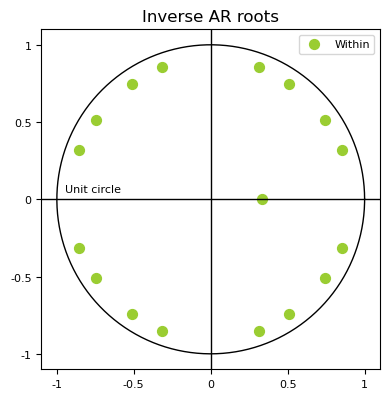

In [54]:
plot_roots(model.arroots)

### **5.4.3) Check residuals**

**In this cell:**
1) The residuals of the fitted model are obtained and analyzed

**Notes:**
- **IMPORTANT**  
The first $p+P$ residuals are removed because the are used as initial values to startup the model.

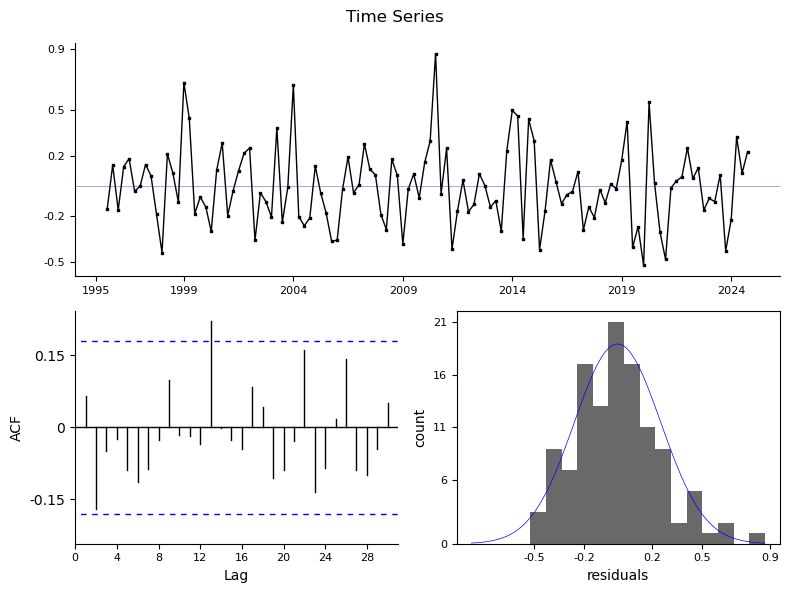

In [55]:
# Calculate the number of residuals to be ommited
p,d,q = order
P,D,Q,S = seasonal_order
n_omit = p + q + P + Q
residuals = model.resid[n_omit:]

# Plot the residuals
plot_residuals(residuals)

### **5.4.4) Validate assumption: No Autocorrelation**

**In this cell:**  
1) A Portmanteau test is applied, with the Ljung-Box modification. It test  to check no autocorrelation.

**Notes:**
- Considers $H_0: \hat{\rho}_i=...=\hat{\rho}_k=0$
- 30 lags are chosen due to the sample size

In [56]:
# Perform the autocorrelation test and get pvalue
pvalue = sm.stats.acorr_ljungbox(residuals, lags=[30]).iloc[0,1]

# Bloack breaker
print("="*100)
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is not rejected.\nAutocorrelation doesn't exist in the residuals!")
print("="*100)

The pvalue is 0.23. Therefore, the Null hypothesis is not rejected.
Autocorrelation doesn't exist in the residuals!


### **5.4.5) Validate assumption: Homoscedasticity**

**In this cell:**
1) An Engle's ARCH test is best suited to perform an homoscedasticity test on the time series context. It checks if the square of the time series is autocorrelated using the lagrange multipliers when fitting an ARCH model for k lags.

**Notes:**
- Considers $H_0: $
- The function provides two approaches: Lagrange multipliers and F-test; the former is considered.

In [57]:
# Perform the homoscedasticity test and get pvalue
pvalue = statsmodels.stats.diagnostic.het_arch(residuals)[1]

# Block breaker
print("="*100)
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is not rejected.\nVariance of the errors is homoscedastic!")
print("="*100)

The pvalue is 0.40. Therefore, the Null hypothesis is not rejected.
Variance of the errors is homoscedastic!


### **5.4.6) Validate assumption: Normality**

**In this cell:**
1) Among all normality test, the best suited for the time series context is Jarque-Bera, which is built upon the skewness and kurtosis.

**Notes:**
- Considers $H_0: \text{Sample is normally distributed}$

In [58]:
# Perform the normality test and get pvalue
pvalue = jarque_bera(residuals)[1]

# Block breaker
print("="*100)
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is rejected.\nErrors are not normally distributed!")
print("="*100)

The pvalue is 0.01. Therefore, the Null hypothesis is rejected.
Errors are not normally distributed!


# **6) Hyperparameter Tuning**

## **6.1) Define auxiliary functions**

**In this cell:**
1) A function to inverse the Box Cox transformation is defined

**Notes:**
- In case of negative lambdas, the inverse might not be defined in the Real numbers and NaN is returned.

In [59]:
def inv_boxcox(y, lam):
    """
    Performs the inverse of the Box Cox transformation.
    y (series): The series to be inversed
    lam (float): The lambda value under which the Box Cox transformation was applied
    """

    # Catch and suppress the RuntimeWarning
    with warnings.catch_warnings():
    
        # Case when lambda is zero
        if lam == 0:
            return np.exp(y)
        
        # Case when lambda is different to zero
        else:
            warnings.simplefilter("ignore", category=RuntimeWarning)
            return (y * lam + 1) ** (1 / lam)

## **6.2 Grid Search**

**In this cell:**
1) Iterate over a grid of hyperparameters
2) Tries to fit the model aand checks if convergence exists.
3) In case the model can be fitted and the solution converges, compute relevant metrics and model validations
4) Performs a backtesting with 8 steps and checks if the forecast of the train model contains the actual observed values
5) Computes the forecast in 8 steps and saves the interval of prediction
6) In case of some error, all results for the model are saved as "-"

**Notes:**
- The gridsearch is done manually because of traceability purposes. THe output is custom and a backtesting is performed for each iteration.

In [114]:
# Define the TS to be fitted by the model
ts_model = ts_transformed
ts_model.index = pd.date_range(start=ts_model.index.min(), periods=len(ts_model), freq="QE")

# Define df and lists to store results
df_results = pd.DataFrame()
res_name, res_fits, res_warnings = [], [], []
res_stationary, res_invertible = [], []
res_significant = []
res_independent, res_homoscedastic, res_normality = [], [], []
res_rmse, res_mae = [], []
res_forecast_interval = []
res_backtest, res_backtest_interval = [], []

# Used to track execution status
i = 0
start_time = time.time()
batch_start_time = time.time()

# Iterate over all possible models and try to fit them
for p in range(4):
    for d in range(5):
        for q in range(4):
            for P in range(5):
                for D in range(5):
                    for Q in range(5):
                        
                        # Define the order of the model
                        # order = (0,1,3)
                        # seasonal_order = (1,2,0,4)
                        # p,d,q = order
                        # P,D,Q,S = seasonal_order
                        name = f"({p},{d},{q}) ({P},{D},{Q})"
                        
                        # Ensure all warnings are captured and capture warnings
                        with warnings.catch_warnings(record=True) as w:
                            warnings.simplefilter("always")
                            try:
                                model = sm.tsa.ARIMA(ts_model, order=(p,d,q), seasonal_order=(P,D,Q,4), trend="n").fit(
                                        method="statespace", method_kwargs={"maxfun": 1000})
                                fits = True
                            except:
                                fits = False
                            warning_free = 0 == len(w)
                        
                        # Case when model is adjusted and had not warnings during fitting
                        if fits * warning_free:

                            # Stationarity check
                            magnitude = np.array([(root.real**2 + root.imag**2)**0.5 for root in (1/model.arroots)])
                            stationary = all(magnitude <= 0.975)

                            # Invertibility check
                            magnitude = np.array([(root.real**2 + root.imag**2)**0.5 for root in (1/model.maroots)])
                            invertible = all(magnitude <= 0.975)

                            # Significance test
                            pvalues = model.pvalues[:-1]
                            if 0 < pvalues.shape[0]:
                                significant = (0.05 >= pvalues).sum() / pvalues.shape[0]
                            else:
                                significant = 0

                            # Get the residuals of the model, skip those irrelevant.
                            n_omit = p + q + P + Q
                            residuals = model.resid[n_omit:]

                            # Independence test of the residuals
                            pvalue = sm.stats.acorr_ljungbox(residuals, lags=[30]).iloc[0,1]
                            independent = pvalue >= 0.05

                            # Homoscedasticity test of the residuals
                            pvalue = statsmodels.stats.diagnostic.het_arch(residuals)[1]
                            homoscedastic = pvalue >= 0.05

                            # Normality test of the residuals
                            pvalue = jarque_bera(residuals)[1]
                            normality = pvalue >= 0.05

                            # Obtain the model evaluation metrics
                            rmse, mae = model.mse**0.5, model.mae
                        
                            # Compute the forecast interval and make the inverse transformation
                            forecast_interval = model.get_forecast(steps=8).summary_frame().iloc[-1,2:5].values
                            forecast_interval = inv_boxcox(forecast_interval, lambda_value)
                            forecast_interval = forecast_interval / (1+forecast_interval)
                            forecast_interval = forecast_interval.max() - forecast_interval.min()

                            # Backtest - Trim TS to perform backtest and fit model
                            h = 8
                            ts_temporal = ts_model[:-h]
                            
                            with warnings.catch_warnings(record=True) as w:
                                warnings.simplefilter("always")
                                try:
                                    model_temporal = sm.tsa.ARIMA(ts_temporal, order=(p,d,q), seasonal_order=(P,D,Q,4), trend="n").fit(
                                                     method="statespace", method_kwargs={"maxfun": 1000})
                                    fits = True
                                except:
                                    fits = False
                                warning_free_temporal = 0 == len(w)

                            # Case when temporal model (backtest) didn't have warnings or was actually fitted
                            if fits*warning_free_temporal:
                                
                                # Backtest - Check if the backtest is valid for all the periods
                                ts_comparison = ts_model[-h:].values
                                ci_comparison = model_temporal.get_forecast(steps=h).summary_frame().iloc[:,2:].values
                                comparison = np.array([[ci_comparison[i][0] <= ts_comparison[i],
                                                        ts_comparison[i] <= ci_comparison[i][1]] for i in range(h)])
                                backtest = comparison.astype(int).sum() == h*2
                                
                                # Backtest - With the inverse transformations obtain the interval of forecast for the backtest
                                backtest_interval = ci_comparison[h-1]
                                backtest_interval = inv_boxcox(backtest_interval, lambda_value)
                                backtest_interval = backtest_interval / (1+backtest_interval)
                                backtest_interval = backtest_interval.max() - backtest_interval.min()
    
                                # Modify results if interval is NAN (out of range for inv_boxcox)
                                forecast_interval = "-" if np.isnan(forecast_interval) else forecast_interval
                                backtest = "-" if np.isnan(backtest_interval) else backtest
                                backtest_interval = "-" if np.isnan(backtest_interval) else backtest_interval

                        # Case when the temporal model (backtest) had warnings or couldn't be fitted
                            else:
                                backtest, backtest_interval = "-", "-"
                            
                        
                        # Case when the model had warnings or couldn't be fitted
                        else:
                            stationary, invertible = "-", "-"
                            significant = "-"
                            independent, homoscedastic, normality = "-", "-", "-"
                            rmse, mae = "-", "-"
                            forecast_interval = "-"
                            backtest, backtest_interval = "-", "-"

                        # Track execution status
                        i += 1
                        if i%25==0:
                            print("="*100+f"\nFitted {i:.0f} models!\n")

                            # Print execution status
                            print(f"Batch fitted in {time.time()-batch_start_time:.0f} seconds")
                            print(f"Total elapsed time: {(time.time()-start_time)/60:.0f} minutes!")
                            batch_start_time = time.time()
                            
                        # Append the results of the model in iteration
                        res_name.append(name), res_fits.append(fits), res_warnings.append(warning_free)
                        res_stationary.append(stationary), res_invertible.append(invertible)
                        res_significant.append(significant)
                        res_independent.append(independent), res_homoscedastic.append(homoscedastic), res_normality.append(normality)
                        res_rmse.append(rmse), res_mae.append(mae)
                        res_forecast_interval.append(forecast_interval)
                        res_backtest.append(backtest), res_backtest_interval.append(backtest_interval)
                        


# Gather together all the results in one single DF
df_results = pd.DataFrame({
    "model":res_name, "fits":res_fits, "warning_free":res_warnings,
    "stationary":res_stationary, "invertible":res_invertible,
    "significant":res_significant,
    "independent":res_independent, "homoscedastic":res_homoscedastic, "normality":res_normality,
    "RMSE":res_rmse, "MAE":res_mae,
    "backtest":res_backtest, "backtest_interval":res_backtest_interval,
    "forecast_interval": res_forecast_interval
})

# Block breaker
print("\n"*3+"="*100)
print("All models were fitted!")
print("="*100)

Fitted 25 models!

Batch fitted in 5 seconds
Total elapsed time: 0 minutes!
Fitted 50 models!

Batch fitted in 9 seconds
Total elapsed time: 0 minutes!
Fitted 75 models!

Batch fitted in 9 seconds
Total elapsed time: 0 minutes!
Fitted 100 models!

Batch fitted in 12 seconds
Total elapsed time: 1 minutes!
Fitted 125 models!

Batch fitted in 17 seconds
Total elapsed time: 1 minutes!
Fitted 150 models!

Batch fitted in 7 seconds
Total elapsed time: 1 minutes!
Fitted 175 models!

Batch fitted in 9 seconds
Total elapsed time: 1 minutes!
Fitted 200 models!

Batch fitted in 12 seconds
Total elapsed time: 1 minutes!
Fitted 225 models!

Batch fitted in 14 seconds
Total elapsed time: 2 minutes!
Fitted 250 models!

Batch fitted in 16 seconds
Total elapsed time: 2 minutes!
Fitted 275 models!

Batch fitted in 9 seconds
Total elapsed time: 2 minutes!
Fitted 300 models!

Batch fitted in 14 seconds
Total elapsed time: 2 minutes!
Fitted 325 models!

Batch fitted in 15 seconds
Total elapsed time: 2 minu

/opt/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/statespace/mlemodel.py:3014: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


Fitted 475 models!

Batch fitted in 21 seconds
Total elapsed time: 4 minutes!
Fitted 500 models!

Batch fitted in 22 seconds
Total elapsed time: 4 minutes!
Fitted 525 models!

Batch fitted in 6 seconds
Total elapsed time: 5 minutes!
Fitted 550 models!

Batch fitted in 9 seconds
Total elapsed time: 5 minutes!
Fitted 575 models!

Batch fitted in 10 seconds
Total elapsed time: 5 minutes!
Fitted 600 models!

Batch fitted in 14 seconds
Total elapsed time: 5 minutes!
Fitted 625 models!

Batch fitted in 18 seconds
Total elapsed time: 5 minutes!
Fitted 650 models!

Batch fitted in 10 seconds
Total elapsed time: 6 minutes!
Fitted 675 models!

Batch fitted in 11 seconds
Total elapsed time: 6 minutes!
Fitted 700 models!

Batch fitted in 14 seconds
Total elapsed time: 6 minutes!
Fitted 725 models!

Batch fitted in 19 seconds
Total elapsed time: 6 minutes!
Fitted 750 models!

Batch fitted in 24 seconds
Total elapsed time: 7 minutes!
Fitted 775 models!

Batch fitted in 14 seconds
Total elapsed time:

/opt/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/statespace/mlemodel.py:3014: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


Fitted 2350 models!

Batch fitted in 22 seconds
Total elapsed time: 25 minutes!
Fitted 2375 models!

Batch fitted in 23 seconds
Total elapsed time: 25 minutes!
Fitted 2400 models!

Batch fitted in 15 seconds
Total elapsed time: 26 minutes!
Fitted 2425 models!

Batch fitted in 20 seconds
Total elapsed time: 26 minutes!
Fitted 2450 models!

Batch fitted in 23 seconds
Total elapsed time: 26 minutes!


...

Fitted 9200 models!

Batch fitted in 25 seconds
Total elapsed time: 217 minutes!


/opt/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/statespace/mlemodel.py:3014: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


Fitted 9225 models!

Batch fitted in 28 seconds
Total elapsed time: 217 minutes!
Fitted 9250 models!

Batch fitted in 44 seconds
Total elapsed time: 218 minutes!
Fitted 9275 models!

Batch fitted in 27 seconds
Total elapsed time: 219 minutes!
Fitted 9300 models!

Batch fitted in 19 seconds
Total elapsed time: 219 minutes!
Fitted 9325 models!

Batch fitted in 26 seconds
Total elapsed time: 219 minutes!
Fitted 9350 models!

Batch fitted in 41 seconds
Total elapsed time: 220 minutes!
Fitted 9375 models!

Batch fitted in 50 seconds
Total elapsed time: 221 minutes!
Fitted 9400 models!

Batch fitted in 31 seconds
Total elapsed time: 221 minutes!
Fitted 9425 models!

Batch fitted in 31 seconds
Total elapsed time: 222 minutes!


/opt/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/statespace/mlemodel.py:3014: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


Fitted 9450 models!

Batch fitted in 36 seconds
Total elapsed time: 222 minutes!
Fitted 9475 models!

Batch fitted in 52 seconds
Total elapsed time: 223 minutes!
Fitted 9500 models!

Batch fitted in 63 seconds
Total elapsed time: 224 minutes!
Fitted 9525 models!

Batch fitted in 15 seconds
Total elapsed time: 225 minutes!
Fitted 9550 models!

Batch fitted in 15 seconds
Total elapsed time: 225 minutes!
Fitted 9575 models!

Batch fitted in 23 seconds
Total elapsed time: 225 minutes!
Fitted 9600 models!

Batch fitted in 30 seconds
Total elapsed time: 226 minutes!
Fitted 9625 models!

Batch fitted in 38 seconds
Total elapsed time: 226 minutes!
Fitted 9650 models!

Batch fitted in 17 seconds
Total elapsed time: 227 minutes!
Fitted 9675 models!

Batch fitted in 24 seconds
Total elapsed time: 227 minutes!
Fitted 9700 models!

Batch fitted in 26 seconds
Total elapsed time: 228 minutes!
Fitted 9725 models!

Batch fitted in 33 seconds
Total elapsed time: 228 minutes!
Fitted 9750 models!

Batch f

## **6.3) Select best model**

**In this cell:**
1) Among all fitted models, the best one is selected. The model should comply with all the validation requirements and have the lowest RMSE.

**Notes:**
- TO select the most useful model, a restriction to the forecast interval is introduced.

In [61]:
df_temporal = df_results
df_temporal["RMSE"] = pd.to_numeric(df_temporal["RMSE"], errors="coerce")
df_temporal["forecast_interval"] = pd.to_numeric(df_temporal["forecast_interval"], errors="coerce")

df_temporal[
    (df_temporal["fits"]) &
    (df_temporal["warning_free"]) &
    (df_temporal["stationary"]) &
    (df_temporal["invertible"]) &
    (df_temporal["significant"] == 1) &
    (df_temporal["independent"]) &
    (df_temporal["homoscedastic"]) &
    (df_temporal["normality"]) &
    (df_temporal["backtest"] == True) &
    (df_temporal["forecast_interval"] <= 0.5) 
].sort_values(["RMSE"]).head(1)

NameError: name 'df_results' is not defined

## **6.4) Validate final model**

### **6.4.1) Fit model with tuned hyperparameters**

**In this cell:**
1) The order of the model is set with tuned hyperparameters, and the model is fit.

**Notes:**
- The order of the model is obtained in the previous cells

In [ ]:
# Set tuned hyperparameters
p,d,q = (2,0,0)
P,D,Q,S = (4,2,0,4)

# Fit final model
model_final = sm.tsa.ARIMA(ts_transformed, order=(p,d,q), seasonal_order=(P,D,Q,4), trend="n").fit(
                           method="statespace", method_kwargs={"maxfun": 1000})

# Cell breaker
print("="*100)
print(f"Final model was fitted.\nOrder: ({p},{d},{q})\nSeasonal Order: ({P},{D},{Q})")
print("="*100)

### **6.4.1) Time series requirements**

**In this cell:**
1) Check the stationarity of the fitted model by checking the AR polynomial

**Notes:**
- All of the inverse of the AR roots fall within the unit circle. Thus, the process is stationary.
- Since no MA component, the TS is also considered invertible

In [ ]:
plot_roots(model_final.arroots)

### **6.4.2) Significance of the coefficients**

**In this cell:**
1) Check the significance of a certain coefficient $\phi=0$ or $\Phi=0$  

**Notes:**  
    - All coefficients result statistically significant

In [ ]:
print("="*100)
print("Level of significance:\n")
print(model_final.pvalues.round(4)[:-1])
print("="*100)

### **6.4.3) Assumptions of the residuals**

**In this cell:**
1) The assumptions on the residuals are tested

**Notes:**
- The model passes all the tests.

In [ ]:
# Calculate the number of residuals to be ommited
n_omit = p + q + P + Q
residuals = model_final.resid[n_omit:]

# Perform the normality test and get pvalue
pvalue = jarque_bera(residuals)[1]
print("="*100)
print("Normality\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the null hypothesis is failed to be rejected.\nErrors are normally distributed!")
print("="*100)

# Perform the homoscedasticity test and get pvalue
pvalue = statsmodels.stats.diagnostic.het_arch(residuals)[1]
print("Homoscedasticity\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is not rejected.\nVariance of the errors is homoscedastic!")
print("="*100)

# Perform the autocorrelation test and get pvalue
pvalue = sm.stats.acorr_ljungbox(residuals, lags=[30]).iloc[0,1]
print("Autocorrelation\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is not rejected.\nAutocorrelation doesn't exist in the residuals!")
print("="*100)

## **6.3) Select best model**

**In this cell:**
1) The best model is selected among all models that comply with requirements.

**Notes:**
- For usefulness purposes, models are filtered by their forecast interval

In [179]:
# Define a temporal df, format and sort it
df_temporal = df_results.copy()
df_temporal["RMSE"] = pd.to_numeric(df_temporal["RMSE"], errors="coerce")
df_temporal["forecast_interval"] = pd.to_numeric(df_temporal["forecast_interval"], errors="coerce")
df_temporal.sort_values(["RMSE"], inplace=True)

# Filter models by requirements
df_temporal[
    (df_temporal["fits"]) &
    (df_temporal["warning_free"]) &
    (df_temporal["stationary"]) &
    (df_temporal["invertible"]) &
    (df_temporal["significant"] == 1) &
    (df_temporal["independent"]) &
    (df_temporal["homoscedastic"]) &
    (df_temporal["normality"]) & 
    (df_temporal["forecast_interval"] <= 0.50)
].head(1)

,model,fits,warning_free,stationary,invertible,significant,independent,homoscedastic,normality,RMSE,MAE,backtest,backtest_interval,forecast_interval
5110,"(2,0,0) (4,2,0)",True,True,True,True,1.0,True,True,True,0.346785,0.260123,True,0.446266,0.209967


## **6.3) Validate best model**

### **6.3.1) Fit final model**

In [180]:
p, d, q = (2,0,0)
P, D, Q = (4,2,0)
model_final = sm.tsa.ARIMA(ts_transformed, order=(p,d,q), seasonal_order=(P,D,Q,4), trend="n").fit(
                           method="statespace", method_kwargs={"maxfun": 1000})

### **6.3.2) Check stationarity**

**In this cell:**
1) The AR roots are checked to ensure stationarity

**Notes:**
- The order q and Q are zero, therefore there's no necessity to check for invertibility

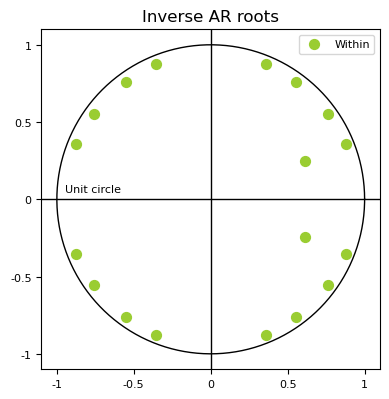

In [181]:
plot_roots(model_final.arroots)

### **6.3.4) Significance of coefficients**

**In this cell:**
1) The statistical significance of the coefficients is tested $(\beta = 0)$

**Notes:**
- All coefficients are statistically different than zero

In [182]:
print("="*100)
print("Level of significance:\n")
print(model_final.pvalues.round(4)[:-1])
print("="*100)

Level of significance:

ar.L1       0.0
ar.L2       0.0
ar.S.L4     0.0
ar.S.L8     0.0
ar.S.L12    0.0
ar.S.L16    0.0
dtype: float64


### **6.3.4) Validate residuals assumptions**

**In this cell:**
1) The statistical test for normality, autocorrelation and homoscedasticity are performed.

**Notes:**
- The residuals of the backtesting models comply with all the assumptions

In [183]:
# Calculate the number of residuals to be ommited
n_omit = p + q + P + Q
residuals = model_final.resid[n_omit:]

# Perform the normality test and get pvalue
pvalue = jarque_bera(residuals)[1]
print("="*100)
print("Normality\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the null hypothesis is failed to be rejected.\nErrors are normally distributed!")
print("="*100)

# Perform the homoscedasticity test and get pvalue
pvalue = statsmodels.stats.diagnostic.het_arch(residuals)[1]
print("Homoscedasticity\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is not rejected.\nVariance of the errors is homoscedastic!")
print("="*100)

# Perform the autocorrelation test and get pvalue
pvalue = sm.stats.acorr_ljungbox(residuals, lags=[30]).iloc[0,1]
print("Autocorrelation\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is not rejected.\nAutocorrelation doesn't exist in the residuals!")
print("="*100)

Normality

The pvalue is 0.08. Therefore, the null hypothesis is failed to be rejected.
Errors are normally distributed!
Homoscedasticity

The pvalue is 0.53. Therefore, the Null hypothesis is not rejected.
Variance of the errors is homoscedastic!
Autocorrelation

The pvalue is 0.72. Therefore, the Null hypothesis is not rejected.
Autocorrelation doesn't exist in the residuals!


# **7) Backtesting**

### **7.1) Fit model for backtesting**

**In this cell:**
1) The backtesting is performed for 8 steps. All the predictions should contain the actual observed values.

**Notes:**
- All validations should be satisfied by the backtesting model

In [184]:
# Define
ts_backtesting = ts_transformed.iloc[:-8]

# Fit final model
model_backtesting = sm.tsa.ARIMA(ts_backtesting, order=(p,d,q), seasonal_order=(P,D,Q,4), trend="n").fit(
                 method="statespace", method_kwargs={"maxfun": 1000})

## **7.2) Validate backtesting model**

### **7.2.1) Stationarity and invertibility**

**In this cell:**
1) The AR roots are checked to ensure stationarity

**Notes:**
- The order q and Q are zero, therefore there's no necessity to check for invertibility

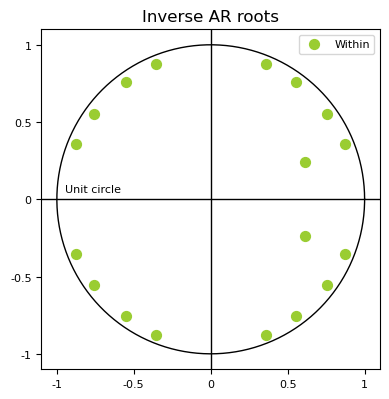

In [185]:
plot_roots(model_backtesting.arroots)

### **7.2.1) Significance of the coefficients**

**In this cell:**
1) The statistical significance of the coefficients is tested $(\beta = 0)$

**Notes:**
- All coefficients are statistically different than zero

In [186]:
print("="*100)
print("Level of significance:\n")
print(model_backtesting.pvalues.round(4)[:-1])
print("="*100)

Level of significance:

ar.L1       0.0000
ar.L2       0.0000
ar.S.L4     0.0000
ar.S.L8     0.0000
ar.S.L12    0.0000
ar.S.L16    0.0002
dtype: float64


### **7.2.3) Residuals assumptions**

**In this cell:**
1) The statistical test for normality, autocorrelation and homoscedasticity are performed.

**Notes:**
- The residuals of the backtesting models comply with all the assumptions

In [187]:
# Calculate the number of residuals to be ommited
n_omit = p + q + P + Q
residuals = model_backtesting.resid[n_omit:]

# Perform the normality test and get pvalue
pvalue = jarque_bera(residuals)[1]
print("="*100)
print("Normality\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the null hypothesis is failed to be rejected.\nErrors are normally distributed!")
print("="*100)

# Perform the homoscedasticity test and get pvalue
pvalue = statsmodels.stats.diagnostic.het_arch(residuals)[1]
print("Homoscedasticity\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is not rejected.\nVariance of the errors is homoscedastic!")
print("="*100)

# Perform the autocorrelation test and get pvalue
pvalue = sm.stats.acorr_ljungbox(residuals, lags=[30]).iloc[0,1]
print("Autocorrelation\n")
print(f"The pvalue is {pvalue:.2f}. Therefore, the Null hypothesis is not rejected.\nAutocorrelation doesn't exist in the residuals!")
print("="*100)

Normality

The pvalue is 0.10. Therefore, the null hypothesis is failed to be rejected.
Errors are normally distributed!
Homoscedasticity

The pvalue is 0.50. Therefore, the Null hypothesis is not rejected.
Variance of the errors is homoscedastic!
Autocorrelation

The pvalue is 0.89. Therefore, the Null hypothesis is not rejected.
Autocorrelation doesn't exist in the residuals!


## **7.3) Perform backtesting**

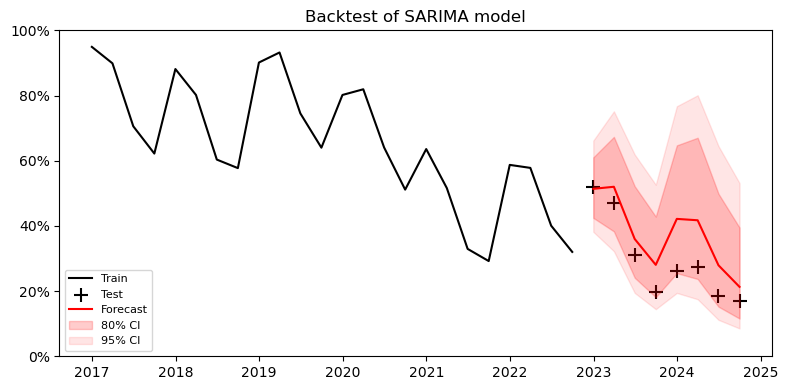

In [188]:
# Create figure
plt.figure(figsize=(8,4))

# Plot train TS, only last 24 observations
temporal = ts_backtesting[-24:]
temporal = inv_boxcox(temporal, lam=lambda_value)
temporal = temporal / (1+temporal)
plt.plot(temporal, color="black", label="Train")

# Plot observed values
temporal = ts_transformed[-8:]
temporal = inv_boxcox(temporal, lam=lambda_value)
temporal = temporal / (1+temporal)
plt.scatter(x=temporal.index, y=temporal, color="black", s=100, marker="+", label="Test")

# Get forecast
forecast = model_backtesting.get_forecast(steps=8).summary_frame()

# Plot forecasted TS (mean)
temporal = forecast["mean"]
temporal = inv_boxcox(temporal, lam=lambda_value)
temporal = temporal / (1+temporal)
plt.plot(temporal, color="red", label="Forecast")

# Plot CI of 80%
upper = pd.Series(index=forecast["mean"].index,
                  data=forecast["mean"] + 1.281*forecast["mean_se"])
upper = inv_boxcox(upper, lam=lambda_value)
upper = upper / (1+upper)
lower = pd.Series(index=forecast["mean"].index,
                  data=forecast["mean"] - 1.281*forecast["mean_se"])
lower = inv_boxcox(lower, lam=lambda_value)
lower = lower / (1+lower)
plt.fill_between(x=upper.index, y1=lower, y2=upper, color="red", alpha=0.20, label="80% CI")

# Plot CI of 95%
upper = pd.Series(index=forecast["mean"].index,
                  data=forecast["mean"] + 1.959*forecast["mean_se"])
upper = inv_boxcox(upper, lam=lambda_value)
upper = upper / (1+upper)
lower = pd.Series(index=forecast["mean"].index,
                  data=forecast["mean"] - 1.959*forecast["mean_se"])
lower = inv_boxcox(lower, lam=lambda_value)
lower = lower / (1+lower)
plt.fill_between(x=upper.index, y1=lower, y2=upper, color="red", alpha=0.10, label="95% CI")

#
plt.ylim(0,1)
yticks = plt.gca().get_yticks()
plt.yticks(yticks, [f"{yt:.0f}%" for yt in yticks * 100]) 
plt.title("Backtest of SARIMA model", fontsize=12)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

# **8) Forecasting**

**In this cell:**
1) The predictions of the storage are presented

**Notes:**
- Remember that the time interval was trimmed to match the original study

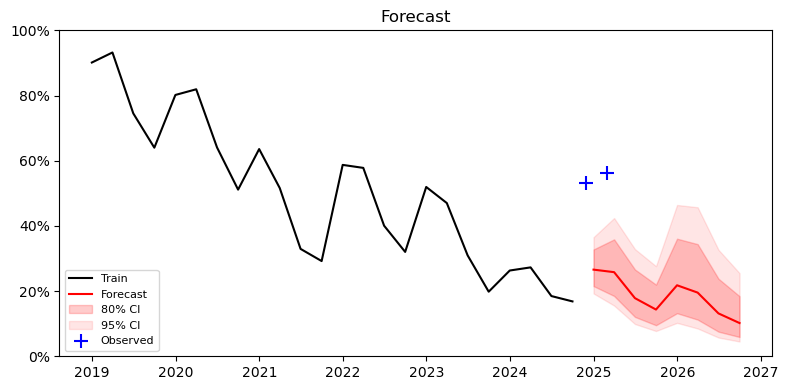

In [189]:
# Create figure
plt.figure(figsize=(8,4))

# Plot the TS, only last 24 observations
temporal = ts_transformed[-24:]
temporal = inv_boxcox(temporal, lam=lambda_value)
temporal = temporal / (1+temporal)
plt.plot(temporal, color="black", label="Train")

# Get forecast
forecast = model_final.get_forecast(steps=8).summary_frame()

# Plot forecasted TS (mean)
temporal = forecast["mean"]
temporal = inv_boxcox(temporal, lam=lambda_value)
temporal = temporal / (1+temporal)
plt.plot(temporal, color="red", label="Forecast")

# Plot CI of 80%
upper = pd.Series(index=forecast["mean"].index,
                  data=forecast["mean"] + 1.281*forecast["mean_se"])
upper = inv_boxcox(upper, lam=lambda_value)
upper = upper / (1+upper)
lower = pd.Series(index=forecast["mean"].index,
                  data=forecast["mean"] - 1.281*forecast["mean_se"])
lower = inv_boxcox(lower, lam=lambda_value)
lower = lower / (1+lower)
plt.fill_between(x=upper.index, y1=lower, y2=upper, color="red", alpha=0.20, label="80% CI")

# Plot CI of 95%
upper = pd.Series(index=forecast["mean"].index,
                  data=forecast["mean"] + 1.959*forecast["mean_se"])
upper = inv_boxcox(upper, lam=lambda_value)
upper = upper / (1+upper)
lower = pd.Series(index=forecast["mean"].index,
                  data=forecast["mean"] - 1.959*forecast["mean_se"])
lower = inv_boxcox(lower, lam=lambda_value)
lower = lower / (1+lower)
plt.fill_between(x=upper.index, y1=lower, y2=upper, color="red", alpha=0.10, label="95% CI")


ts_temporal = ts_storage_complete[ts_storage_complete.index > ts_storage.index.max()]
ts_temporal = (ts_temporal-namino) / (namo-namino)
plt.scatter(x=ts_temporal.index, y=ts_temporal, label="Observed", marker="+", s=100, color="blue")

#
plt.ylim(0,1)
yticks = plt.gca().get_yticks()
plt.yticks(yticks, [f"{yt:.0f}%" for yt in yticks * 100]) 
plt.title("Forecast", fontsize=12)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()